# Fictional Telecommunications Data Analysis

The dataset covers data from a fictional telco company. The records in this dataset pertain to customer demographics information ranging from the customer's attributes, location, personal status, financial gain, and service usage.

This analysis aims to identify churn patterns, which pertain customers cancelling their subscription, that may appear and the reason as to why. This analysis also aims to identify the general interest of customers based on their demographics.

The insights derived from this analysis may help in understanding how a customer uses the telecommunication company's services. It may also help in identifying ways in promoting and marketing to improve customer rate and customer retention.

At the end of this analysis, a Logistic Regression model is applied to answer these questions.

Additionally, a simple model will also be built to predict the occurence of rain, trained using the dataset.


## Data Analysis Objectives

This project aims to satisfy the following objectives:
- Preprocess the dataset to be applicable for a machine learning model
- Identify factors that are driving customer churn
- Identify factors that are important in maintaining and further improving customer retention. 
- Develop a Logistic Regression model to predict customers that are at risk of churning 


## Data Exploration

Before we begin, let us first import the dataset and take a look before proceeding.

In [134]:

from datasets import load_dataset 
ds = load_dataset("aai510-group1/telco-customer-churn")

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

As seen below, the dataset is already split between a 60-20-20 train-test-validation split. This is particularly common for a dataset with a relatively small overall size.

This dataset contains a total of 7043 records, hence, a split of 60-20-20 is perfectly reasonable.

Source: https://towardsdatascience.com/model-validation-techniques-explained-a-visual-guide-with-code-examples-eb13bbdc8f88/

In [25]:
# Takes the entire row count of the telecommunications dataset.
total = sum(len(dataset) for dataset in ds.values())

# Displays the row count and percentage of each split in the dataset.
for split, dataset in ds.items():
    percentage = len(dataset) / total * 100
    print(f"{split}: {len(dataset):,} rows ({percentage:.2f}%)")
    
print("Total Rows:", total)

train: 4,225 rows (59.99%)
validation: 1,409 rows (20.01%)
test: 1,409 rows (20.01%)
Total Rows: 7043


We can convert the dataset into a Pandas datatype for proper display and convenience.

In [55]:
import pandas as pd

train_df = ds["train"].to_pandas()
test_df = ds["test"].to_pandas()
validation_df = ds["validation"].to_pandas()

Below is a showcase of the training dataset's first 5 records. As we can see from below, the dataset contains 52 columns, mostly numerical, with categorical data such as 'City', 'Churn Category', and 'Contract'. 

In [56]:
# Pandas for easier visualization in a tabular format.
train_df.head(5)

,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,Churn Category,Churn Reason,Churn Score,City,CLTV,Contract,...,Streaming TV,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data,Zip Code
0,72,4,19.44,0,None,None,51,San Mateo,4849,Two Year,...,0,25,2191.15,0,486.00,0.0,2677.15,0,1,94403
1,27,59,45.62,0,None,None,27,Sutter Creek,3715,Month-to-Month,...,1,35,3418.20,0,1596.70,0.0,5014.90,1,1,95685
2,59,0,16.07,0,None,None,59,Santa Cruz,5092,Month-to-Month,...,0,46,851.20,0,739.22,0.0,1590.42,0,0,95064
3,25,27,0.00,0,None,None,49,Brea,2068,One Year,...,0,27,1246.40,30,0.00,0.0,1276.40,1,0,92823
4,31,21,17.22,1,Dissatisfaction,Network reliability,88,San Jose,4026,One Year,...,0,58,3563.80,0,998.76,0.0,4562.56,0,1,95117


Below, we can also check out the features or columns of the dataset in a more compressed manner. The info() methods allows for a summarized version, displaying the columns, their type, how many non-null values and null values each column has.

In [57]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4225 entries, 0 to 4224
Data columns (total 52 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                4225 non-null   int64  
 1   Avg Monthly GB Download            4225 non-null   int64  
 2   Avg Monthly Long Distance Charges  4225 non-null   float64
 3   Churn                              4225 non-null   int64  
 4   Churn Category                     1121 non-null   object 
 5   Churn Reason                       1121 non-null   object 
 6   Churn Score                        4225 non-null   int64  
 7   City                               4225 non-null   object 
 8   CLTV                               4225 non-null   int64  
 9   Contract                           4225 non-null   object 
 10  Country                            4225 non-null   object 
 11  Customer ID                        4225 non-null   objec

Below, we can check out important demographic information for the customers. This gives us important context on the scenario itself.

As we can see, the dataset all surround the state of California, United States. There is almost an even 50-50 split in gender, with 2124 male and 2101 female customers. Meanwhile, we have 1121 churned customers in the training split.

In [83]:
identifier_cols = ['City', 'Country', 'State', 'Gender', 'Customer Status', 'Contract', 'Internet Type']

for column in identifier_cols:
    print(f"\n===== {column} =====")
    print(train_df[column].value_counts(dropna=False))


===== City =====
City
Los Angeles      175
San Diego        168
San Francisco     61
San Jose          61
Sacramento        60
                ... 
San Bruno          1
Salida             1
Lewiston           1
Casmalia           1
Sloughhouse        1
Name: count, Length: 1085, dtype: int64

===== Country =====
Country
United States    4225
Name: count, dtype: int64

===== State =====
State
California    4225
Name: count, dtype: int64

===== Gender =====
Gender
Male      2124
Female    2101
Name: count, dtype: int64

===== Customer Status =====
Customer Status
Stayed     2832
Churned    1121
Joined      272
Name: count, dtype: int64

===== Contract =====
Contract
Month-to-Month    2193
Two Year          1128
One Year           904
Name: count, dtype: int64

===== Internet Type =====
Internet Type
Fiber Optic    1829
DSL            1008
No Internet     886
Cable           502
Name: count, dtype: int64


I also would like to check how the dataset is split based on how many customers Churned. Using the *Customer Status* column, we can identify that the dataset has an equivalent class distribution across the three splits.

This means that the three splits are satisfactory. It is slightly **imbalanced** with a 74-26 ratio of Retention-Churned, but it is not heavily imabalanced and can still be considered fairly balanced. This is important since models aim to maximize accuracy. If a model is skewed towards a particular class, it will aim to mostly guess towards that class, leading to its prediction being incorrect. 

A balanced dataset prevents bias and ensures we are able to use this model in a real world setting.

In [87]:
print(train_df['Customer Status'].value_counts(dropna=False))
print(test_df['Customer Status'].value_counts(dropna=False))
print(validation_df['Customer Status'].value_counts(dropna=False))

Train: 26.53% Churned
Test: 26.54% Churned
Validation: 26.54% Churned


Firstly, I want to look into the *Satisfaction Score*, as that may have an indication on the *Churn* status of customers. I looked into if the binary column Churn and compared with the Satisfactory Score to check the values, and have observed that most customers who churned are  those with a satisfactory score of 1-3, while those that didn't were on 3-5. 

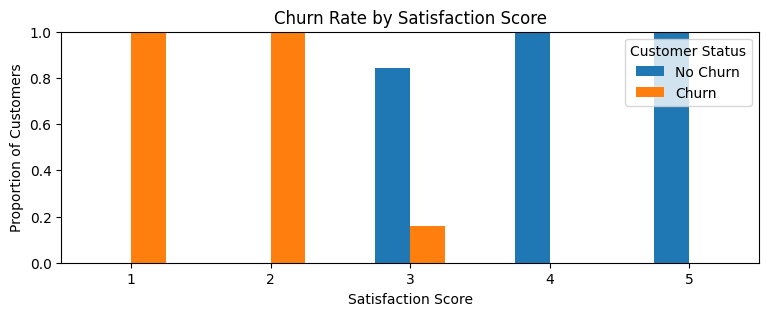

In [146]:
satisfaction_churn = (
    train_df.groupby('Satisfaction Score')['Churn']
      .value_counts(normalize=True)
      .unstack(fill_value=0)
)

# Rename columns for readability
satisfaction_churn = satisfaction_churn.rename(
    columns={0: 'No Churn', 1: 'Churn'}
)

# Plot both
satisfaction_churn.plot(
    kind='bar',
    figsize=(9, 3)
)

plt.title('Churn Rate by Satisfaction Score')
plt.xlabel('Satisfaction Score')
plt.ylabel('Proportion of Customers')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title='Customer Status')
plt.show()

In [140]:
train_df['Tenure in Months']

0       25
1       35
2       46
3       27
4       58
        ..
4220     1
4221    22
4222    18
4223    57
4224    17
Name: Tenure in Months, Length: 4225, dtype: int64

Next, I took a look into the Churn rate as the time of service went on, using *Tenure in Months*. From here, we can observe that those who haven't used the service yet for a year are the most likely ones to churn. 

This trend continues in a downward manner, where the more tenured customers are more likely to stay and retain their use of the service.

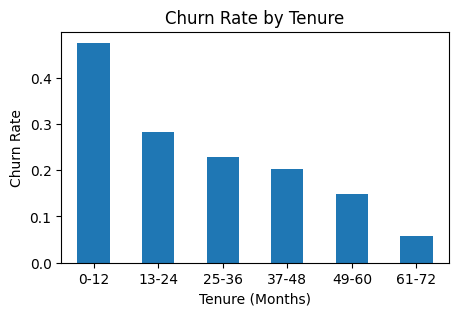

In [144]:
train_copy = train_df.copy()
train_copy['Tenure Group'] = pd.cut(
    train_copy['Tenure in Months'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
)

tenure_churn = (
    train_copy.groupby('Tenure Group', observed=False)['Churn']
      .apply(lambda x: (x == 1).mean())
)

tenure_churn.plot(
    kind='bar',
    figsize=(5, 3)
)

plt.title('Churn Rate by Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.show()

Next, we can take a look into how customers churn based on their contract. There are only 3 types of contracts here, Month-to-Month, One Year, Two Year.

From the graph below, customers with shorter-term contracts tend to churn while customers with longer-term contracts are expected to stay. This is a common event especially for users who want to try using the product for a month before committing to it and extending their contract.

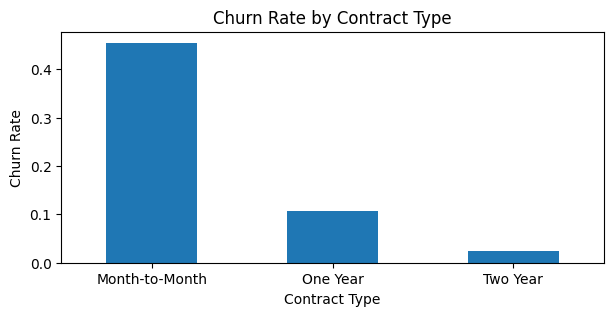

In [150]:
churn_rate = (
    train_copy.groupby('Contract')['Churn']
      .value_counts(normalize=True)
      .unstack()
)

churn_rate[1].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(7, 3)
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.show()

Now that exploration has been implemented, based on the features observed, I am hypothesizing that the following features will be strong features:
* Contract - Customers on shorter contracts have less commitment and may be more likely to leave to try other products.
* Tenure in Months - Newer customers may have a higher likelihood of churning, while long-term customers are committed.
* Satisfaction Score - Unhappy customers are more likely to leave.
* Monthly Charge - Higher monthly costs may increase the likelihood of customers switching to competitors and leaving.
* Number of Referrals and Number of Dependents - Customers who actively refer others may be more engaged with the service.

## Data Preprocessing

### Handling Missing Values

Next, we can also observe from the .info() method output that there are columns which are have a non-null value different from the rest. This indicates that these features have a 'null' or 'None' value. Which we will be handling next.

Let us first begin by trying to check out which columns in our dataset have these null values across the three splits.

In [58]:
def check_null_columns(dataset: pd.DataFrame) -> None:
    """Identify columns containing null values in a DataFrame.

    Args:
        dataset (pd.DataFrame): The DataFrame used for identifying null columns.
    """

    null_columns = dataset.columns[dataset.isnull().any()]

    if len(null_columns) > 0:
        print("Columns with null values:")
        for column in null_columns:
            print(f"- {column}: {dataset[column].isnull().sum()} null values")
    else:
        print("No columns with null values.")


for split, dataset in {
    "Train": train_df,
    "Test": test_df,
    "Validation": validation_df
}.items():
    print(f"\n{split} Split")
    check_null_columns(dataset)


Train Split
Columns with null values:
- Churn Category: 3104 null values
- Churn Reason: 3104 null values
- Internet Type: 886 null values
- Offer: 2324 null values

Test Split
Columns with null values:
- Churn Category: 1035 null values
- Churn Reason: 1035 null values
- Internet Type: 308 null values
- Offer: 762 null values

Validation Split
Columns with null values:
- Churn Category: 1035 null values
- Churn Reason: 1035 null values
- Internet Type: 332 null values
- Offer: 791 null values


As we can see, all 3 datasets have a commonality when it came to the missing values. They all stemmed from the same 3 columns:
* Churn Category
* Churn Reason
* Internet Type
* Offer

To further contextualize these four columns, let us take a sample look into them.

In [59]:
# Our columns with null values.
columns = ["Churn Category", "Churn Reason", "Internet Type", "Offer"]

df = train_df[columns]

df.head(10)

,Churn Category,Churn Reason,Internet Type,Offer
0,None,None,Fiber Optic,None
1,None,None,Fiber Optic,None
2,None,None,None,None
3,None,None,DSL,None
4,Dissatisfaction,Network reliability,Cable,Offer B
5,Competitor,Competitor had better devices,Cable,Offer E
6,None,None,Fiber Optic,None
7,Price,Price too high,Fiber Optic,Offer B
8,None,None,Fiber Optic,Offer A
9,None,None,DSL,None


These four columns are explainable as to why they are missing. Missing values aren't necessarily indicative of missing data. In this case, it is easy to understand as to why these are missing.
* Offer - Offer refers to the marketing offer that the customer accepted. If this is null, the customer simply had no offer given to them or they didn't accept an offer.
* Internet Type - This is simply the type of internet service availed by the customer. A null value means no internet service was recorded for the customer.

On the other hand, the former two columns, *Churn Category* and *Churn Reason* are very important in our dataset. These are closely related to the *Churn* column, and together, these are the indicators that specify if a customer has churned/left the service. 

In [61]:
# Columns to Replace
columns = ["Churn Category", "Churn Reason", "Internet Type", "Offer"]

# Fill null values across the three datasets with appropriate values.
for df in [train_df, test_df, validation_df]:
    df["Offer"] = df["Offer"].fillna("No Offer")
    df["Internet Type"] = df["Internet Type"].fillna("No Internet")
    df["Churn Category"] = df["Churn Category"].fillna("Did Not Churn")
    df["Churn Reason"] = df["Churn Reason"].fillna("Did Not Churn")

And after running, we can use the check_null_columns that we defined to see if there are any more columns that are null. As we can see, we are now ready to proceed.

In [62]:

for split, dataset in {
    "Train": train_df,
    "Test": test_df,
    "Validation": validation_df
}.items():
    print(f"\n{split} Split")
    check_null_columns(dataset)## Outlier Detection


Train Split
No columns with null values.

Test Split
No columns with null values.

Validation Split
No columns with null values.


### Handling Outliers

#### Categorical Outliers

Now is the time to see if there are any columns that go past beyond their logical point or become outliers. First, we will look into categorical fields for any outliers.

As seen below, there are no erroneous categories or any categories that are different from their respective column. The only categories that had a large number were *Lat Long* and *Customer ID* since they are both of Object type, but each feather very unique values.

In conclusion, we can move on to numerical values.

In [80]:
categorical_cols = train_df.select_dtypes(include="object").columns

for column in categorical_cols:
    print(f"\n===== {column} =====")
    print(train_df[column].value_counts(dropna=False))


===== Churn Category =====
Churn Category
Did Not Churn      3104
Competitor          486
Attitude            200
Dissatisfaction     171
Other               134
Price               130
Name: count, dtype: int64

===== Churn Reason =====
Churn Reason
Did Not Churn                                3104
Competitor had better devices                 188
Competitor made better offer                  187
Attitude of support person                    136
Don't know                                     87
Attitude of service provider                   64
Competitor offered more data                   57
Competitor offered higher download speeds      54
Network reliability                            46
Price too high                                 44
Product dissatisfaction                        42
Long distance charges                          39
Service dissatisfaction                        32
Moved                                          32
Extra data charges                             2

#### Numerical Outliers

To begin checking the numerical values if there are any outliers, I will first split the binary columns from the numerical/continuous values. 

A binary column is one where its values are 0 or 1, and this is observable in columns such as *Churn* or *Gender*.

We can identify the columns that aren't binary by excluding them and making a new list.

In [88]:

binary_cols = [
    column for column in train_df.columns
    if train_df[column].nunique() == 2
]

numeric_cols = train_df.select_dtypes(include="number").columns

continuous_cols = [
    column for column in numeric_cols
    if column not in binary_cols
]

print(continuous_cols)

['Age', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges', 'Churn Score', 'CLTV', 'Latitude', 'Longitude', 'Monthly Charge', 'Number of Dependents', 'Number of Referrals', 'Population', 'Satisfaction Score', 'Tenure in Months', 'Total Charges', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Refunds', 'Total Revenue']


Next, outliers usually persist if they exceed any interquartile range, but this isn't an indication of outliers.

The code below takes the columns that exceed the interquartile range, and we will be investigating those that violate that range.

Now that we have identified that these data are likely MAR (Missing at Random), we would still need to manage these missing records for our analysis. We can go ahead and manage the null values across all three datasets with the following:
* Offer - No Offer
* Internet - No Internet
* Churn Category - Did Not Churn
* Churn Reason - Did Not Churn

In [90]:
outlier_columns =[]

# Loop through all continuous columns to identify outliers using the IQR method.
# The columns were identified in the previous code block.
for column in continuous_cols:
    Q1 = train_df[column].quantile(0.25)
    Q3 = train_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = (
        (train_df[column] < lower) |
        (train_df[column] > upper)
    ).sum()

    if outlier_count > 0:
        print(f"{column}: {outlier_count:,} outliers")
        outlier_columns.append(column)
    

Avg Monthly GB Download: 211 outliers
Number of Dependents: 985 outliers
Number of Referrals: 413 outliers
Population: 33 outliers
Satisfaction Score: 549 outliers
Total Extra Data Charges: 450 outliers
Total Long Distance Charges: 108 outliers
Total Refunds: 320 outliers
Total Revenue: 14 outliers


We can already knock off some columns that were tagged as outliers, such as *Satisfaction Score*, *Population*.

Population was identified as having 33 statistical outliers using IQRmethod. However, these values should not be considered erroneous because Population represents the population associated with a customer's ZIP code rather than the customer's individual characteristics. Multiple customers living within the same ZIP code can therefore legitimately have the same population value.

Similarly, *Satisfaction Score* produced 549 records as outliers. However, this variable is a discrete rating on a scale of 1 to 5, rather than a continuous measurement. 

This extends to *Number of Dependents* and *Number of Dependents*. Despite not having a scale, are discrete values that range from 0 to 8 and 0 to 11 respectively as seen below.

In [107]:
print(train_df["Satisfaction Score"].value_counts().sort_index())

print(train_df["Number of Dependents"].value_counts().sort_index())

print(train_df["Number of Referrals"].value_counts().sort_index())

Satisfaction Score
1     549
2     314
3    1622
4    1044
5     696
Name: count, dtype: int64
Number of Dependents
0    3240
1     337
2     315
3     316
4       7
5       8
6       1
8       1
Name: count, dtype: int64
Number of Referrals
0     2282
1      642
2      136
3      158
4      137
5      160
6      130
7      167
8      116
9      149
10     146
11       2
Name: count, dtype: int64


Next, *Avg Monthly GB Download* had 211 observations classified as outliers. However, these observations have a realistic range of approximately 0–85 GB per month and can represent a legitimate customers' data usage.

In [118]:
# Prints the minimum and maximum of Avg Monthly GB Download
print(f"Avg Monthly GB Download: min = {train_df['Avg Monthly GB Download'].min()}, max = {train_df['Avg Monthly GB Download'].max()}")

Avg Monthly GB Download: min = 0, max = 85


Next, we can observe the remaining continuous variables which are the following:
* Total Extra Data Charges
* Total Long Distance Charges
* Total Refunds
* Total Revenue

To observe these, I graphed a histogram plot of the values shown below. The bar graph is binned to group data values into 10 groups.

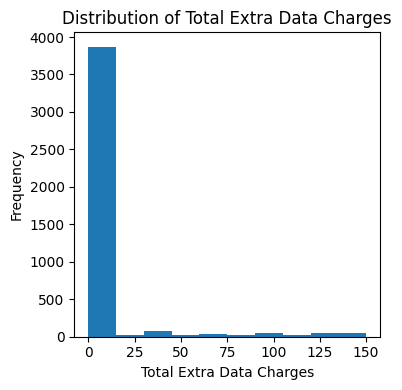

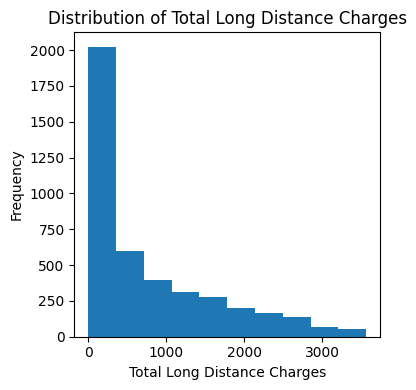

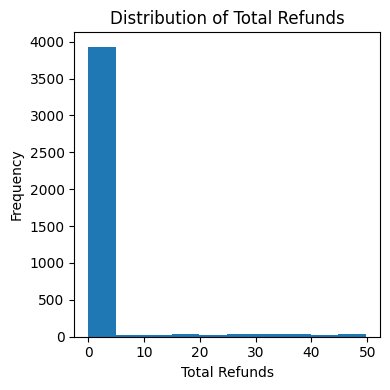

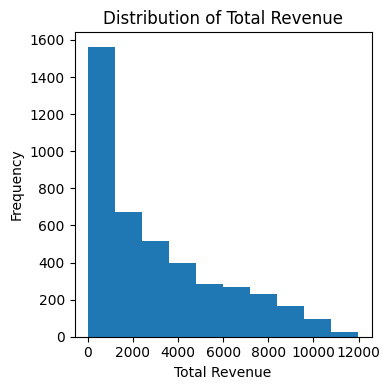

In [132]:
import matplotlib.pyplot as plt

columns = [
    "Total Extra Data Charges",
    "Total Long Distance Charges",
    "Total Refunds",
    "Total Revenue"
]

for column in columns:
    plt.figure(figsize=(4,4))

    train_df[column].plot(
        kind="hist",
        bins=10
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

As we can observe, there is a right skew distribution within these 4 datasets, though it is less obvious in the Total Extra Data Charges and Total Refunds. 

Still, we can observe that the right skew distribution is consistent and there isn't a particular data value that heavily manipulates the histogram. Meaning we can safely say that there are also no outliers within these columns.

### Feature Engineering

Before we begin, let us first lighten our workload a bit by splitting the X and y's of our dataset. 

This involves taking our target *Churn*, and creating the output columns for the 3 datasets.

In [164]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

target = 'Churn'

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

X_validation = validation_df.drop(columns=[target])
y_validation = validation_df[target]


Next, I believe it is time to remove the columns we don't need.
* Churn Category, Churn Reason, Churn Score - This column is only useful after churn, it doesn't help contextualize why the customer churned
* Customer Status - This will cause the model to have a bias since Customer Status describes if a customer has churned or stayed.
* Customer ID - Unique Identifier
* Lat Long - We already have a latitude and longtitude column for geographic information
* Country, State - Since we are in California, we can remove these two columns.



In [166]:
drop_columns = [
    'Churn Category',
    'Churn Reason',
    'Churn Score',
    'Customer Status',
    'Customer ID',
    'Lat Long',
    'Country',
    'State'
]

X_train = X_train.drop(columns=drop_columns, errors='ignore')
X_test = X_test.drop(columns=drop_columns, errors='ignore')
X_validation = X_validation.drop(columns=drop_columns, errors='ignore')

#### Data Encoding

For this dataset, I used the One-Hot Encoding method for categorical variables such as Contract, Internet Type, and Payment Method, as they do not have any ordinal scaling. 

In [171]:
numerical_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['Age', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges', 'CLTV', 'Dependents', 'Device Protection Plan', 'Internet Service', 'Latitude', 'Longitude', 'Married', 'Monthly Charge', 'Multiple Lines', 'Number of Dependents', 'Number of Referrals', 'Online Backup', 'Online Security', 'Paperless Billing', 'Partner', 'Phone Service', 'Population', 'Premium Tech Support', 'Referred a Friend', 'Satisfaction Score', 'Senior Citizen', 'Streaming Movies', 'Streaming Music', 'Streaming TV', 'Tenure in Months', 'Total Charges', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Refunds', 'Total Revenue', 'Under 30', 'Unlimited Data']
Categorical features: ['City', 'Contract', 'Gender', 'Internet Type', 'Offer', 'Payment Method', 'Quarter', 'Zip Code']


#### Data Normalization

We will then create the preprocessor for scaling. Scaling is important in models as it allows for a standardized dataset. Meaning, all data will be treated as if they are among an equal scale. This allows for values like currency that is typically large to not heavily the influence the model, and for lesser values like categorical values to also be considered and have an impact on the model.

For this, we will apply **StandardScaler**.

In [180]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            drop='first'
        ), categorical_features)
    ]
)

Let us apply this transformation across our train, test, and validation sets.

In [181]:
X_train_processed = preprocessor.fit_transform(X_train)



X_test_processed = preprocessor.transform(X_test)


X_validation_processed = preprocessor.transform(X_validation)



c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Since we used **OneHotEncoding**, this creates multiple features that expand our dataset. This is because one-hot encoding converts categories into binary values. For example, the column **Internet Type** have multiple categories (Fiber Optic, No Internet, DSL). This will create multiple columns that can be referred to as "Has Fiber Optic", "Has DSL", "Has Cable". Resulting in the final feature count of 2725.

In [183]:
print("Train Final feature count:", X_train_processed.shape[1])
print("Test Final feature count:", X_test_processed.shape[1])
print("Validation Final feature count:", X_validation_processed.shape[1])

Train Final feature count: 2725
Test Final feature count: 2725
Validation Final feature count: 2725


The data was cleaned by removing identifiers and variables that directly describe the churn outcome, which could give the model clues on what to predict. 

Categorical information was then converted into separate indicators so that categories such as contract type and payment method could be compared without having any ranks between them. 

Numerical variables were then standardized so that features with large values, such as total charges, do not affect the logistic regression model compared with smaller-scale variables such as age.

After preprocessing, the dataset contained 2725 predictive features.

## Model Training

### Training Logistic Regression

We can begin with creating the baseline model with sklearn's LogisticRegression with the following hyperparameters:
* C = 1.0 - The default regularization value. It usually helps the model to stay simple.
* solver = 'liblinear' - Works good for binary logistic regression and can handle  high-dimensional datasets.
* max_iter = 1000 - Setting to only 1000 so that the model doesn't run for way too long and can converge after 1000 iterations.

In [202]:
# Import LogisticRegression from sklearn.linear_model
from sklearn.linear_model import LogisticRegression

# Create a Logistic Regression model with specified hyperparameters
logreg = LogisticRegression(
    C=1.0,
    solver='liblinear',
    max_iter=1000,
)

logreg.fit(X_train_processed, y_train)

# Creating a model that is balanced
logreg_balanced = LogisticRegression(
    C=1.0,
    solver='liblinear',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

logreg_balanced.fit(X_train_processed, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

Next, we can proceed with testing the model with the processed training and test set as is.

Accuracy simply means how many records match from the dataset that were predicted. Meaning, how many customers that churned and didn't churn were properly identified.

In [209]:
from sklearn.metrics import accuracy_score
import pandas as pd

# The predict method is used to generate predictions for the training, validation, and test datasets.
train_pred = logreg.predict(X_train_processed)
val_pred = logreg.predict(X_validation_processed)
test_pred = logreg.predict(X_test_processed)

# We will be scoring the model's performance using accuracy as the evaluation metric. 
# The accuracy_score function from sklearn.metrics calculates the accuracy for each dataset.
accuracy_results = pd.DataFrame({
    'Dataset': ['Training', 'Validation', 'Test'],
    'Accuracy': [
        accuracy_score(y_train, train_pred),
        accuracy_score(y_validation, val_pred),
        accuracy_score(y_test, test_pred)
    ]
})

accuracy_results

,Dataset,Accuracy
0,Training,0.984615
1,Validation,0.967353
2,Test,0.962385


After comparing the training, validation, and test accuracies, we can see that they are extremely high. The relatively small difference between the training and validation/test scores indicates that the model does not show any overfitting nor underfitting for that matter. This indicates that the **baseline model** generalizes reasonably well.

## Model Evaluation

We can proceed with evaluating the model. The most common metrics used for a model like Logistic Regression are the Precision and Recall.

We can see that the Precision of 97% and 94% for No Churn and Churn respectively means that the model can correctly predict those who leave and those who don't. Of all the customers that were predicted to have churned, 94% of those predictions were correct.

For Recall of 92% on Churn, of all the customers who churned, the model guessed 92%. This is the reason **Recall is more important**, since the primary basis for a high recall is if the model can guess those who churned.

In [210]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    test_pred,
    target_names=['No Churn', 'Churn']
))

              precision    recall  f1-score   support

    No Churn       0.97      0.98      0.97      1035
       Churn       0.94      0.92      0.93       374

    accuracy                           0.96      1409
   macro avg       0.95      0.95      0.95      1409
weighted avg       0.96      0.96      0.96      1409



Next, we can display the confusion matrix, which essentially tells us how many were identified:
* True Positive (TP)/Top Left: A customer churned and was correctly identified.
* False Negative (FN)/Lower Left: A customer churned but the model predicted that they would stay.
* False Positive (FP)/Top Right: The model predicted churn, but the customer stayed.
* True Negative (TN)/Lower Right: The model predicted no churn, and the customer did stay.

True Negatives : 1012
False Positives: 23
False Negatives: 30
True Positives : 344


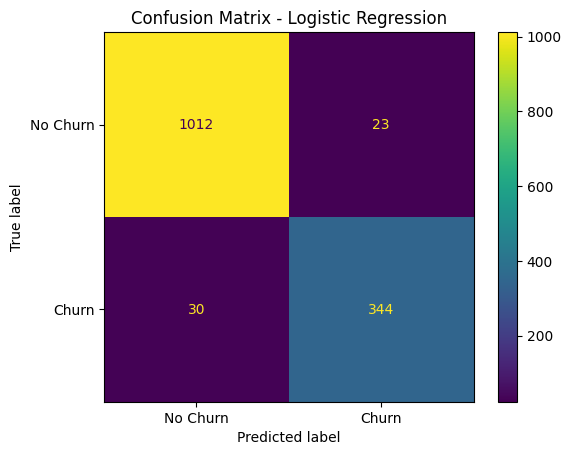

In [196]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

disp.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

False negatives usually have a higher business cost because these are the customers who churned without being identified for possible retention efforts.

These could be retained customers that would've been beneficial for the telecommunications company, but since they were retained, profits were lost. And if these aren't identified, then there would be an increase in losses in the future.

Next, we can use the ***ROC-AUC*** curve, which simple measures if the model can accurately predict, rather than just guess.

With an ROC-AUC value of 0.99 or 99.31%, we can say that the model performs better than just randomly guessing. The closer the AUC reaches 0.50 or 50%, we are essentially guessing the values, but a 1.00 means we can clearly identify rather than guess.

ROC-AUC: 0.9931437133483169


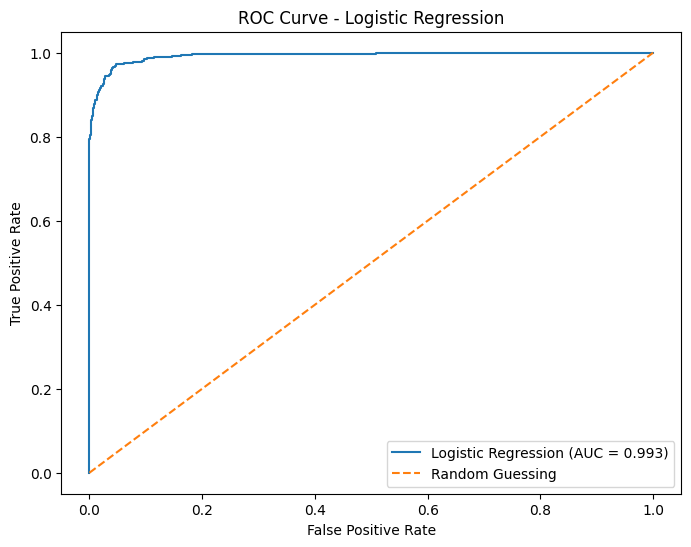

In [197]:
from sklearn.metrics import roc_auc_score, roc_curve

test_prob = logreg.predict_proba(X_test_processed)[:, 1]

roc_auc = roc_auc_score(y_test, test_prob)

print("ROC-AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, test_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Guessing'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

The logistic regression model achieved an accuracy of **96.24%** on the **test dataset**. This performance indicates significant generalization. The model achieved a **ROC-AUC of 99.31%**, meaning it can easily distinguish between customers who churn and those who remain. 

Following that, the confusion matrix shows that the model correctly identified **344 churners**, while **30** churners were missed.

For the improvement of the business, improving **recall** could help identify customers, targeting them for retention campaigns.


### Balanced Comparison

In [203]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Baseline
baseline_pred = logreg.predict(X_test_processed)
baseline_prob = logreg.predict_proba(X_test_processed)[:, 1]

# Balanced
balanced_pred = logreg_balanced.predict(X_test_processed)
balanced_prob = logreg_balanced.predict_proba(X_test_processed)[:, 1]

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Baseline': [
        accuracy_score(y_test, baseline_pred),
        precision_score(y_test, baseline_pred),
        recall_score(y_test, baseline_pred),
        f1_score(y_test, baseline_pred),
        roc_auc_score(y_test, baseline_prob)
    ],
    'Balanced': [
        accuracy_score(y_test, balanced_pred),
        precision_score(y_test, balanced_pred),
        recall_score(y_test, balanced_pred),
        f1_score(y_test, balanced_pred),
        roc_auc_score(y_test, balanced_prob)
    ]
})

comparison

,Metric,Baseline,Balanced
0,Accuracy,0.962385,0.958126
1,Precision,0.937330,0.886978
2,Recall,0.919786,0.965241
3,F1-Score,0.928475,0.924456
4,ROC-AUC,0.993144,0.993084


After evaluation, I decided to try evaluate the 'balanced' model since there is a 76-24 ratio class imbalance of No Churn to Churn.

The updated model's performance was compared against the baseline using accuracy, precision, recall, F1-score, and ROC-AUC. Although as we can observe, the original baseline model has better resulting metrics, and the **performance didn't improve**.

This may be due to the fact that the model places greater emphasis on correctly identifying churners, also known as the minority class. Since we 'balanced' the dataset, we emphasized more on the Churn, which was 26% lesser than the No Churn.

### Threshold Comparison

Since our threshold is at a 0.5 probability, this essentially treats the two events of Churn and No Churn to occur equally. We can adjust this threshold to try and get closer to reality, identifying more churners, but may cause more incorrect predictions.

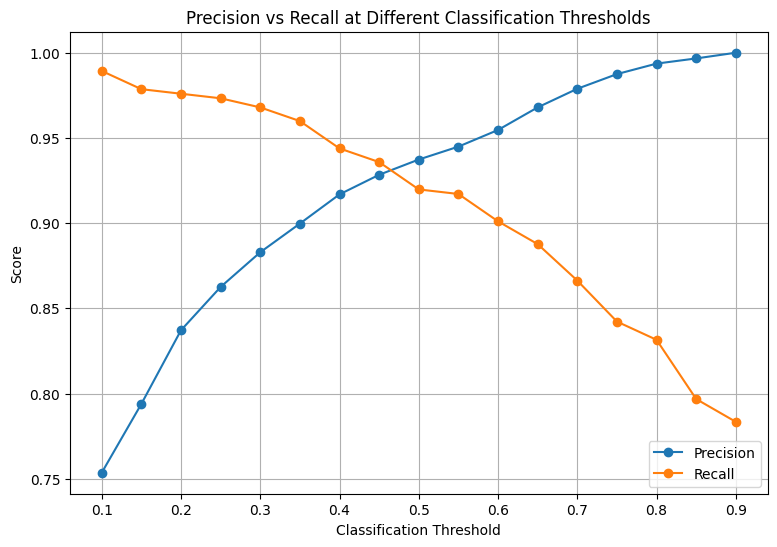

In [ ]:
import numpy as np

# Get predicted probability of churn
test_prob = logreg.predict_proba(X_test_processed)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

# Test the thresholds in the range of 0.10 to 0.90 with a step size of 0.05
# Adds to the result list.
for threshold in thresholds:
    predictions = (test_prob >= threshold).astype(int)

    results.append({
        'Threshold': threshold,
        'Precision': precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        'Recall': recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        'F1-Score': f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(results)

# Graphs the precision and recall scores against the classification thresholds.
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results['Threshold'],
    threshold_results['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_results['Threshold'],
    threshold_results['Recall'],
    marker='o',
    label='Recall'
)

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Classification Thresholds')
plt.legend()
plt.grid(True)

plt.show()

As we can see, as we increase the threshold, the precision-recall graph converges, but diverges at around 0.45 to 0.5, and slowly becomes opposites of each other.

I took the highest F1-score to identify the best threshold result, and it resulted with **0.45**. Lowering the threshold by a bit from 0.5 increased **recall and f1-score** because more customers were classified as potential churners, but this also increased the **false positives** and **reduced precision**. 

Based on the observed precision-recall tradeoff, a threshold of **0.45** provides an appropriate balance for that tradeoff.

In [206]:
best_row = threshold_results.loc[
    threshold_results['F1-Score'].idxmax()
]

print(best_row)

Threshold    0.450000
Precision    0.928382
Recall       0.935829
F1-Score     0.932091
Name: 7, dtype: float64


## Feature Importance

In [198]:
feature_names = preprocessor.get_feature_names_out()

coefficients = logreg.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute Coefficient': abs(coefficients)
})

coef_df = coef_df.sort_values(
    'Absolute Coefficient',
    ascending=False
)

coef_df.head(20)

,Feature,Coefficient,Absolute Coefficient
22,num__Satisfaction Score,-6.286594,6.286594
13,num__Number of Referrals,-1.895110,1.895110
1120,cat__Contract_Two Year,-1.764045,1.764045
868,cat__City_San Diego,1.312820,1.312820
15,num__Online Security,-1.163437,1.163437
534,cat__City_Lakewood,0.950850,0.950850
10,num__Monthly Charge,0.914430,0.914430
1151,cat__Zip Code_90024,0.902527,0.902527
717,cat__City_Olivehurst,0.899968,0.899968
2596,cat__Zip Code_95961,0.899968,0.899968


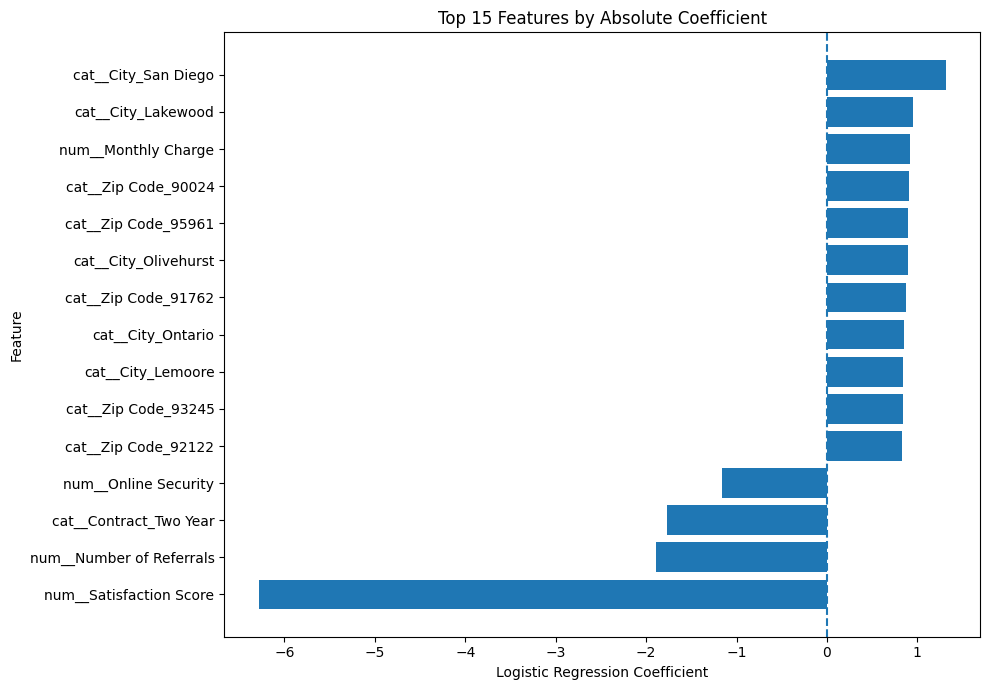

In [199]:
top_features = coef_df.head(15).sort_values('Coefficient')

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.axvline(0, linestyle='--')

plt.xlabel('Logistic Regression Coefficient')
plt.ylabel('Feature')
plt.title('Top 15 Features by Absolute Coefficient')

plt.tight_layout()
plt.show()

The coefficient graph above indicates that **Satisfaction Score** is the strongest predictor of the Churn, higher satisfaction means a lower likelihood of Churn, followed by **Number of Referrals** and having a **Two-Year Contract**. Several location-based features, particularly cities such as **San Diego and Lakewood**, show positive associations.

### Business Insights

In [200]:
top_increase = (
    coef_df[coef_df['Coefficient'] > 0]
    .sort_values('Coefficient', ascending=False)
    .head(5)
)

top_increase

,Feature,Coefficient,Absolute Coefficient
868,cat__City_San Diego,1.312820,1.312820
534,cat__City_Lakewood,0.950850,0.950850
10,num__Monthly Charge,0.914430,0.914430
1151,cat__Zip Code_90024,0.902527,0.902527
717,cat__City_Olivehurst,0.899968,0.899968


Increase Churn Risk:
* City: San Diego: +1.313 - Customers in San Diego have the higheest predicted likelihood of churning.
* City: Lakewood: +0.951 - Customers here have the second highest predicted likelihood of churning.
* Monthly Charge: +0.914 - Higher monthly charges are associated with a higher likelihood of churn.
* Zip Code 90024: +0.903 - Customers in this ZIP code have a higher predicted likelihood of churning.
* City: Olivehurst: +0.900 - Customers here also have a higher predicted likelihood of churning.

In [201]:
top_decrease = (
    coef_df[coef_df['Coefficient'] < 0]
    .sort_values('Coefficient', ascending=True)
    .head(5)
)

top_decrease

,Feature,Coefficient,Absolute Coefficient
22,num__Satisfaction Score,-6.286594,6.286594
13,num__Number of Referrals,-1.895110,1.895110
1120,cat__Contract_Two Year,-1.764045,1.764045
15,num__Online Security,-1.163437,1.163437
1476,cat__Zip Code_92102,-0.744023,0.744023


Decrease Churn Risk:
- Satisfaction Score: -6.287 - Higher satisfaction score means higher chance of retention and lower likelihood of churn.
- Number of Referrals: -1.895 - Customers with more referrals tend to have a lower likelihood of churning. These customers may be really sold on the service.
- Contract: Two Year: -1.764 - Customers on two-year contracts have a lower likelihood of churn, especially since they are in a committed long-term contract.
- Online Security: -1.163- Customers with online security are associated with a lower likelihood of churn.
- Zip Code: 92102: -0.744 - Customers in this ZIP code have a lower likelihood of churn.

###  Business Validation

Some of these findings do make sense. As hypothesized, some features like Satisfaction Score and Cotnract Type had an effect on the likelihood of Churn. It makes sense that Satisfaction Score that is high have a negative coefficient, since customers typically would stay with a product they are happy with.

On another note, customers on a long-term contract would be more willing to honor the contract and continue using the service, in this case, for two years. This goes similarly for referrals. Customers who really trust a product will refer it to more people, friends or family.

Lastly, on the other hand, locations do matter. San Diego is a very populated city in California. Meaning, more people will generally tend to churn as opposed to lesser populated cities. The monhtly charges also greatly affect a customer's reasoning to stay with a service. They may want to move since they do not have the budget, or rather go for something cheaper.

https://www.sciencedirect.com/science/article/pii/S2666720726001384

Fig. 3. Comparison of the most influential features identified by SHAP for IBM Telco and Cell2Cell.



This study above, MetaLight-ChurnNet: A leakage-safe embedding-enhanced ensemble framework for telecom customer churn prediction, gathered an ensemble framework in customer churn prediction from IBM Telco and Cell2Cell with Random Forest Classification.

In terms of feature importance, there are similarities along with IBM Telco, such as Month-to-month Contracts and Monthly Charges. Unfortunately, this fictional dataset doesn't have other features featured in these two Telcos, which have a high importance in customer churn prediction.

A discrepancy visible is that IBM Telco had a high score on tenure, but this dataset did not, which was one of the hypothesized important features.

### Actionable Insights

Finally, here are some of the actionable insights I can provide given the output of the model itself.

1. **Promotion of longer-term contracts with a reasonable price** - The company should encourage a monthly basis of extending the contracts of customers in a monthly contract to a **longer-term contract**. They can also provide discounts and incentives that may sway the customer to consider, given the **monhtly charges** having a large impact on customer churn.

2. **Prioritize customers reporting low satisfaction** - To improve satisfaction, the company should follow-up on customers, providing surveys, customer-service interventions, and open feedback when satisfaction scores decline. Knowing the feedback is key to improving customer satisfaction.

3. **Consider promotion towards highly populated cities** - The company can consider a city like San Diego, with the 2nd largest California population, to expand efforts when it comes to promoting and marketing. They could also focus on customers here to improve customer retention as it is the most impactful one causing churn.